# Agrupamento de Municípios do RJ por K-Means

Agrupar os 92 municípios do Rio de Janeiro em perfis semelhantes de saneamento básico, usando o algoritmo K-Means

## 1. Carregamento dos dados

In [104]:
def parse_br(val):
    if pd.isna(val) or val == "":
        return None
    s = str(val).strip().strip('"')
    if s in ("", " "):
        return None
    s = s.replace(".", "").replace(",", ".")
    try:
        return float(s)
    except ValueError:
        return None

path = "../data/processed/dados_saneamento_snis_sinisa.csv"
hdr = pd.read_csv(path, nrows=0, skiprows=[0, 1], encoding="utf-8", keep_default_na=False).columns.tolist()
df = pd.read_csv(path, skiprows=[0, 1, 2], header=None, dtype=str, encoding="utf-8")
df.columns = hdr

text_cols = {"ano", "id_municipio", "nome_municipio", "sigla_uf"}
for c in [c for c in df.columns if c not in text_cols]:
    df[c] = df[c].apply(parse_br)
df["ano"] = df["ano"].astype(int)
df["id_municipio"] = df["id_municipio"].astype(str).str.strip()

ultimo_ano = df["ano"].max()
print(f"Último ano disponível: {ultimo_ano}")
print(f"Total de linhas: {len(df)}, Colunas: {len(df.columns)}")
df.head()

Último ano disponível: 2024
Total de linhas: 2324, Colunas: 62


,ano,id_municipio,nome_municipio,sigla_uf,populacao_total_residente,populacao_urbana,populacao_atendida_agua,populacao_urbana_atendida_agua,indice_atendimento_urbano_agua,indice_atendimento_total_agua,...,massa_per_capita_limpeza_urbana,massa_per_capita_coleta_seletiva,massa_per_capita_recuperados,desempenho_coleta_seletiva,disposicao_final_inadequada_rsu,recuperacao_reciclaveis_secos_gravimetrica,recuperacao_reciclaveis_organicos_gravimetrica,recuperacao_total_reciclaveis,recuperacao_reciclaveis_secos,recuperacao_reciclaveis_organicos
0,1995,3300407,Barra Mansa,RJ,NaN,164495.0,167000.0,NaN,101.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1995,3303906,Petrópolis,RJ,NaN,257674.0,153000.0,NaN,59.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1995,3304557,Rio de Janeiro,RJ,NaN,5606497.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1996,3300407,Barra Mansa,RJ,NaN,162495.0,169000.0,NaN,104.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1996,3300456,Belford Roxo,RJ,NaN,399319.0,380000.0,NaN,95.2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [105]:
df_atual = df[df["ano"] == ultimo_ano].copy()

pop_urb = df_atual["populacao_urbana"]
pop_tot = df_atual["populacao_total_residente"]
df_atual["pct_populacao_urbana"] = np.where(
    pop_tot.notna() & (pop_tot > 0),
    (pop_urb / pop_tot * 100).round(1),
    np.nan,
)

print(f"Municípios no ano {ultimo_ano}: {len(df_atual)}")
df_atual[["nome_municipio", "populacao_total_residente", "pct_populacao_urbana"]].head(10)

Municípios no ano 2024: 91


,nome_municipio,populacao_total_residente,pct_populacao_urbana
2233,Angra dos Reis,179120.0,97.7
2234,Aperibé,11420.0,91.8
2235,Araruama,137773.0,96.0
2236,Areal,NaN,NaN
2237,Armação dos Búzios,42442.0,100.0
2238,Arraial do Cabo,32794.0,100.0
2239,Barra do Piraí,98501.0,97.3
2240,Barra Mansa,181688.0,98.9
2241,Belford Roxo,518263.0,100.0
2242,Bom Jardim,29736.0,77.5


## 2. Definição das variáveis 

6 variáveis:

| Variável | Fonte | Descrição |
|---|---|---|
| `indice_atendimento_total_agua` | SNIS | Cobertura de água (% da população) |
| `indice_coleta_esgoto` | SNIS | Cobertura de coleta de esgoto (%) |
| `cobertura_residuos_solidos` | SINISA | Cobertura de coleta de resíduos sólidos (%) |
| `disposicao_final_inadequada_rsu` | SINISA | Disposição final inadequada de RSU (%) |
| `pct_populacao_urbana` | IBGE/SNIS | Percentual de população urbana (%) |
| `indice_perda_distribuicao_agua` | SNIS | Perda na distribuição de água (%) |

In [125]:
FEATURES = [
    "indice_atendimento_total_agua",
    "indice_coleta_esgoto",
    "cobertura_residuos_solidos",
    "disposicao_final_inadequada_rsu",
    "pct_populacao_urbana",
    "indice_perda_distribuicao_agua",
]

LABELS = {
    "indice_atendimento_total_agua": "Água (%)",
    "indice_coleta_esgoto": "Esgoto (%)",
    "cobertura_residuos_solidos": "Resíduos (%)",
    "disposicao_final_inadequada_rsu": "Disp. Inadequada (%)",
    "pct_populacao_urbana": "Pop. Urbana (%)",
    "indice_perda_distribuicao_agua": "Perda Água (%)",
}

## 3. Tratamento de dados faltantes

- Municípios com até 2 variáveis faltantes: valores ausentes são preenchidos pela mediana estadual
- Municípios com mais2 variáveis faltantes: são excluídos da análise

In [126]:
df_cl = df_atual[["id_municipio", "nome_municipio"] + FEATURES].copy()

print("Dados faltantes ANTES do tratamento:")
for c in FEATURES:
    n = df_cl[c].isna().sum()
    print(f"  {LABELS[c]:25s} → {n:3d} nulos ({n/len(df_cl)*100:.0f}%)")

n_missing = df_cl[FEATURES].isna().sum(axis=1)
print(f"\nDistribuição de nulos por município:")
print(n_missing.value_counts().sort_index().to_string())

Dados faltantes ANTES do tratamento:
  Água (%)                  →   4 nulos (4%)
  Esgoto (%)                →  25 nulos (27%)
  Resíduos (%)              →   3 nulos (3%)
  Disp. Inadequada (%)      →   3 nulos (3%)
  Pop. Urbana (%)           →   6 nulos (7%)
  Perda Água (%)            →   4 nulos (4%)

Distribuição de nulos por município:
0    58
1    24
2     7
3     1
4     1


In [127]:
excluidos = df_cl[n_missing > 2][["nome_municipio"]].copy()
excluidos["nulos"] = n_missing[n_missing > 2].values
if len(excluidos) > 0:
    print(f"{len(excluidos)} municípios EXCLUÍDOS (mais de 2 variáveis faltantes):")
    display(excluidos)
else:
    print("Nenhum município excluído.")

medianas = df_cl[FEATURES].median()
print(f"\nMedianas estaduais usadas para imputação:")
for c in FEATURES:
    print(f"  {LABELS[c]:25s} → {medianas[c]:.1f}")

df_cl.loc[n_missing <= 2, FEATURES] = df_cl.loc[n_missing <= 2, FEATURES].fillna(medianas)
df_cl = df_cl.dropna(subset=FEATURES).reset_index(drop=True)

print(f"\nMunicípios incluídos na clusterização: {len(df_cl)}")

2 municípios EXCLUÍDOS (mais de 2 variáveis faltantes):


,nome_municipio,nulos
2246,Cambuci,3
2258,Engenheiro Paulo de Frontin,4



Medianas estaduais usadas para imputação:
  Água (%)                  → 97.9
  Esgoto (%)                → 72.4
  Resíduos (%)              → 100.0
  Disp. Inadequada (%)      → 0.0
  Pop. Urbana (%)           → 94.0
  Perda Água (%)            → 36.6

Municípios incluídos na clusterização: 89


## 4. Análise exploratória das variáveis

distribuição de cada variável.

In [128]:
print("Estatísticas descritivas:")
df_cl[FEATURES].describe().round(1).rename(columns=LABELS)

Estatísticas descritivas:


,Água (%),Esgoto (%),Resíduos (%),Disp. Inadequada (%),Pop. Urbana (%),Perda Água (%)
count,89.0,89.0,89.0,89.0,89.0,89.0
mean,90.9,62.3,95.9,10.7,89.4,39.5
std,15.0,32.2,6.6,29.4,12.5,19.0
min,28.2,0.0,71.3,0.0,40.4,8.5
25%,89.2,32.0,94.1,0.0,82.2,25.4
50%,97.9,72.4,100.0,0.0,94.0,36.6
75%,100.0,86.7,100.0,0.0,98.4,46.7
max,100.0,100.0,100.0,100.0,100.0,99.1


In [138]:
corr = df_cl[FEATURES].corr().round(2)
corr_display = corr.rename(index=LABELS, columns=LABELS)

print("Matriz de correlação entre as variáveis:\n")
display(corr_display.style
    .background_gradient(cmap="RdBu_r", vmin=-1, vmax=1)
    .format("{:.2f}")
)

Matriz de correlação entre as variáveis:



,Água (%),Esgoto (%),Resíduos (%),Disp. Inadequada (%),Pop. Urbana (%),Perda Água (%)
Água (%),1.00,0.24,0.04,-0.03,0.09,-0.18
Esgoto (%),0.24,1.00,-0.08,-0.09,-0.03,-0.17
Resíduos (%),0.04,-0.08,1.00,-0.06,0.35,-0.06
Disp. Inadequada (%),-0.03,-0.09,-0.06,1.00,-0.22,-0.14
Pop. Urbana (%),0.09,-0.03,0.35,-0.22,1.00,0.13
Perda Água (%),-0.18,-0.17,-0.06,-0.14,0.13,1.00


## 5. Normalização (escala 0–1)

Aplicamos a **normalização mínimo-máximo** (MinMaxScaler) para que todas as variáveis fiquem entre 0 e 1.

Fórmula: $x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$

Sem isso, variáveis com escalas maiores dominariam o cálculo de distância do K-Médias.

In [111]:
X = df_cl[FEATURES].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=[LABELS[f] for f in FEATURES])
print("Dados normalizados (primeiras 5 linhas):")
df_scaled.head()

Dados normalizados (primeiras 5 linhas):


,Água (%),Esgoto (%),Resíduos (%),Disp. Inadequada (%),Pop. Urbana (%),Perda Água (%)
0,0.888533,0.64190,1.0,0.0,0.961409,0.141171
1,1.000000,0.54000,1.0,0.0,0.862416,0.353921
2,1.000000,0.78000,1.0,0.0,0.932886,0.150877
3,1.000000,0.72365,1.0,0.0,0.899329,0.002978
4,0.972133,0.90000,1.0,0.0,1.000000,0.390758


In [112]:
print("Verificação da normalização (min e max devem ser 0 e 1):")
df_scaled.describe().loc[["min", "max"]].round(3)

Verificação da normalização (min e max devem ser 0 e 1):


,Água (%),Esgoto (%),Resíduos (%),Disp. Inadequada (%),Pop. Urbana (%),Perda Água (%)
min,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0


## 6. Escolha do número de grupos (k)

Testamos k de 2 a 6 e avaliamos com dois métodos:

- **Método do Cotovelo (inércia):** A inércia é a soma das distâncias de cada ponto ao centro do seu grupo. Procuramos o ponto onde a curva "dobra" — a partir daí, adicionar mais grupos traz pouco ganho.

- **Pontuação de Silhueta:** Mede coesão interna e separação entre grupos. Varia de -1 a +1. O k com maior silhueta produz os grupos mais bem definidos.

In [113]:
K_range = range(2, 7)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"k={k}: Inércia={km.inertia_:.2f}, Silhueta={sil:.4f}")

best_k = list(K_range)[np.argmax(sil_scores)]
if best_k < 3:
    print(f"\nSilhueta máxima em k={best_k}, mas forçando k=4 conforme regras.md")
    best_k = 4
else:
    print(f"\n→ Melhor k pela silhueta: {best_k} (silhueta = {max(sil_scores):.4f})")

k=2: Inércia=24.65, Silhueta=0.3300
k=3: Inércia=17.67, Silhueta=0.3798
k=4: Inércia=14.28, Silhueta=0.3604
k=5: Inércia=12.34, Silhueta=0.3690
k=6: Inércia=11.16, Silhueta=0.3813

→ Melhor k pela silhueta: 6 (silhueta = 0.3813)


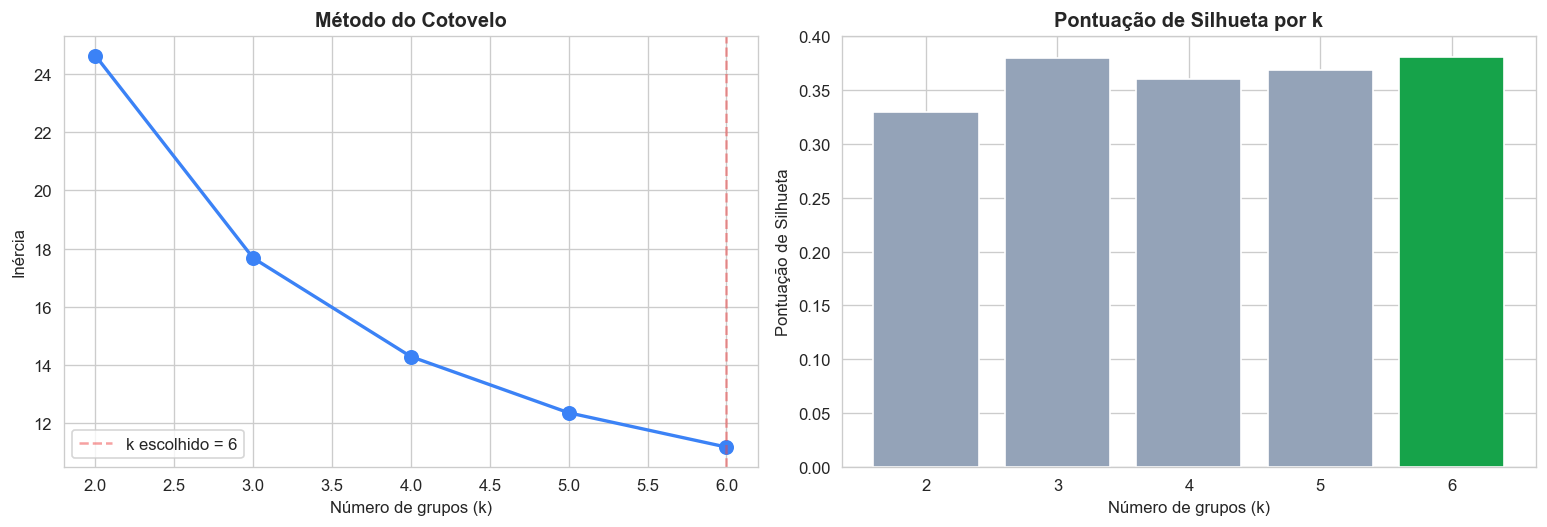

In [114]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(list(K_range), inertias, "o-", color="#3b82f6", lw=2, markersize=8)
ax1.set_xlabel("Número de grupos (k)")
ax1.set_ylabel("Inércia")
ax1.set_title("Método do Cotovelo", fontweight="bold")
ax1.axvline(best_k, color="#ef4444", ls="--", alpha=0.5, label=f"k escolhido = {best_k}")
ax1.legend()

colors = ["#16a34a" if k == best_k else "#94a3b8" for k in K_range]
ax2.bar(list(K_range), sil_scores, color=colors, edgecolor="white")
ax2.set_xlabel("Número de grupos (k)")
ax2.set_ylabel("Pontuação de Silhueta")
ax2.set_title("Pontuação de Silhueta por k", fontweight="bold")

plt.tight_layout()
plt.show()

## 7. Execução final do K-Médias

Rodamos o algoritmo com o k selecionado. O parâmetro `n_init=10` executa o algoritmo 10 vezes com inicializações diferentes e escolhe o resultado com menor inércia. O `random_state=42` garante reprodutibilidade.

In [115]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cl["cluster"] = km_final.fit_predict(X_scaled)

print(f"Distribuição dos municípios por grupo:")
print(df_cl["cluster"].value_counts().sort_index().to_string())
print(f"\nInércia final: {km_final.inertia_:.2f}")
print(f"Silhueta final: {silhouette_score(X_scaled, df_cl['cluster']):.4f}")

Distribuição dos municípios por grupo:
cluster
0     2
1    42
2    17
3     9
4    11
5     8

Inércia final: 11.16
Silhueta final: 0.3813


## 8. Análise de Silhueta por município

A silhueta individual mostra quão bem cada município se encaixa no seu grupo. Valores próximos de +1 indicam boa classificação; valores negativos indicam que o município talvez pertença a outro grupo.

In [ ]:
sil_vals = silhouette_samples(X_scaled, df_cl["cluster"])
df_cl["silhueta"] = sil_vals

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 0
cores = sns.color_palette("Set2", best_k)

for i in range(best_k):
    vals = np.sort(sil_vals[df_cl["cluster"] == i])
    size = len(vals)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, color=cores[i], label=f"Grupo {i}")
    ax.text(-0.05, y_lower + size / 2, f"Grupo {i}", fontsize=9, va="center")
    y_lower = y_upper + 2

ax.axvline(sil_vals.mean(), color="red", ls="--", lw=1, label=f"Média: {sil_vals.mean():.3f}")
ax.set_xlabel("Pontuação de Silhueta")
ax.set_ylabel("Municípios")
ax.set_title("Silhueta individual por grupo", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

mal_classificados = df_cl[df_cl["silhueta"] < 0][["nome_municipio", "cluster", "silhueta"]]
if len(mal_classificados) > 0:
    print(f"\n{len(mal_classificados)} municípios com silhueta negativa (possível reclassificação):")
    display(mal_classificados.sort_values("silhueta"))
else:
    print("\nTodos os municípios têm silhueta positiva.")

KeyError: 'cluster'

## 9. Perfil médio de cada grupo

Calculamos a média de cada variável por grupo para entender o que caracteriza cada agrupamento.

In [117]:
profiles = df_cl.groupby("cluster")[FEATURES].agg(["mean", "std"]).round(1)
profiles_mean = df_cl.groupby("cluster")[FEATURES].mean().round(1)

def nome_cluster(row):
    agua = row.get("indice_atendimento_total_agua", 0)
    esgoto = row.get("indice_coleta_esgoto", 0)
    pct_urb = row.get("pct_populacao_urbana", 50)
    residuos = row.get("cobertura_residuos_solidos", 0)
    if agua > 70 and esgoto > 60 and residuos > 60:
        return "Saneamento avançado"
    if agua > 60 and esgoto < 40:
        return "Água adequada, esgoto deficiente"
    if pct_urb < 60:
        return "Município rural vulnerável"
    return "Déficit estrutural"

nomes = {i: nome_cluster(profiles_mean.loc[i]) for i in profiles_mean.index}
df_cl["grupo"] = df_cl["cluster"].map(nomes)

display_profiles = profiles_mean.copy()
display_profiles.index = [nomes[i] for i in display_profiles.index]
display_profiles = display_profiles.rename(columns=LABELS)

print("Perfil médio de cada grupo:")
display(display_profiles)

Perfil médio de cada grupo:


,Água (%),Esgoto (%),Resíduos (%),Disp. Inadequada (%),Pop. Urbana (%),Perda Água (%)
Déficit estrutural,30.1,13.2,100.0,0.0,90.4,51.8
Saneamento avançado,96.5,82.8,98.8,0.4,91.8,32.1
"Água adequada, esgoto deficiente",90.9,10.0,96.3,0.0,92.7,42.6
Déficit estrutural,88.9,52.9,95.7,95.8,82.1,31.5
Saneamento avançado,95.2,77.6,83.0,6.3,80.0,40.7
Saneamento avançado,73.2,68.0,97.0,0.5,90.7,76.1


## 10. Visualização em 2D (Análise de Componentes Principais)

A ACP reduz as 6 variáveis a 2 eixos principais, preservando a maior variação possível dos dados. Isso permite visualizar os agrupamentos em um gráfico de dispersão.

In [119]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df_cl["pca1"] = coords[:, 0]
df_cl["pca2"] = coords[:, 1]

print(f"Variância explicada pelo Componente 1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variância explicada pelo Componente 2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total explicado (2 componentes): {sum(pca.explained_variance_ratio_)*100:.1f}%")

Variância explicada pelo Componente 1: 30.2%
Variância explicada pelo Componente 2: 25.0%
Total explicado (2 componentes): 55.2%


In [120]:
print("Contribuição de cada variável original nos componentes:")
loadings = pd.DataFrame(
    pca.components_.T,
    index=[LABELS[f] for f in FEATURES],
    columns=["Componente 1", "Componente 2"],
).round(3)
display(loadings)

Contribuição de cada variável original nos componentes:


,Componente 1,Componente 2
Água (%),0.239,0.031
Esgoto (%),0.918,0.208
Resíduos (%),-0.053,-0.241
Disp. Inadequada (%),-0.280,0.850
Pop. Urbana (%),0.015,-0.350
Perda Água (%),-0.139,-0.229


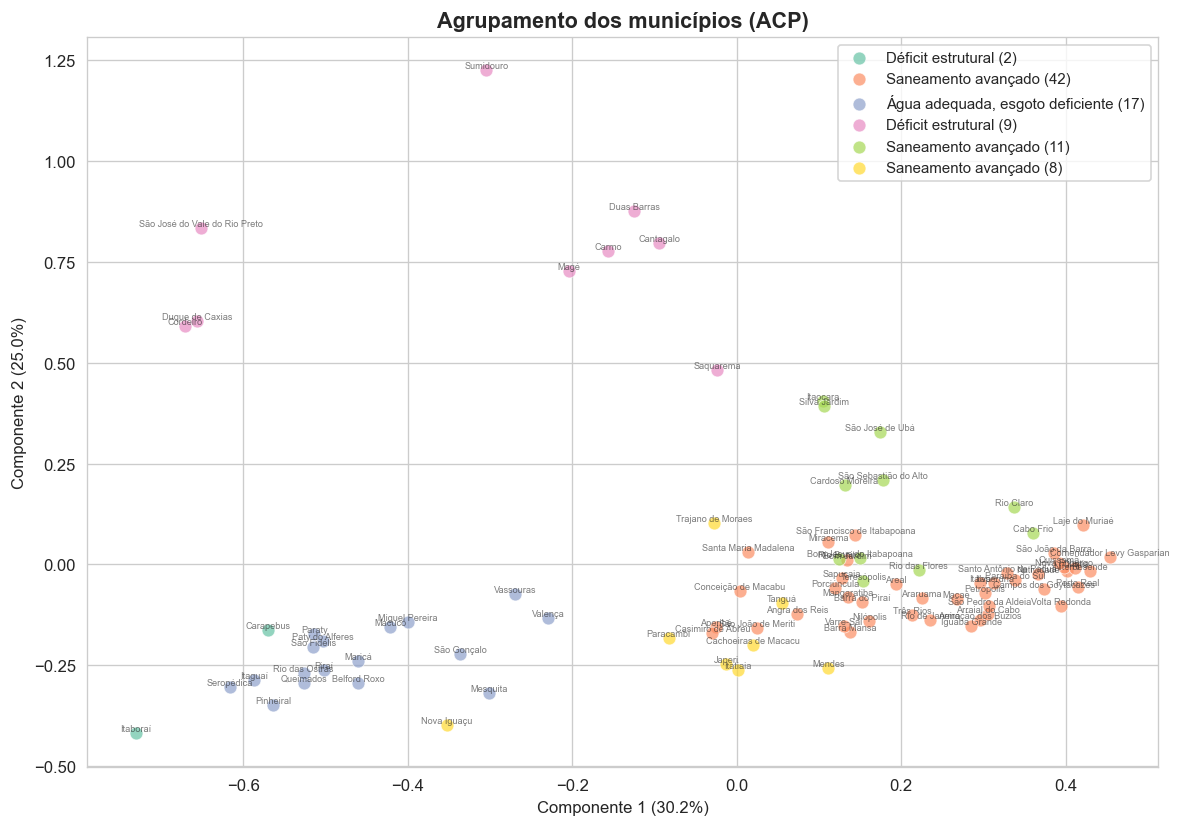

In [121]:
fig, ax = plt.subplots(figsize=(10, 7))
cores = sns.color_palette("Set2", best_k)

for i in range(best_k):
    mask = df_cl["cluster"] == i
    ax.scatter(df_cl.loc[mask, "pca1"], df_cl.loc[mask, "pca2"],
               c=[cores[i]], s=60, alpha=0.7, edgecolors="white", lw=0.5,
               label=f"{nomes[i]} ({mask.sum()})")

for _, row in df_cl.iterrows():
    ax.annotate(row["nome_municipio"], (row["pca1"], row["pca2"]),
                fontsize=5.5, alpha=0.6, ha="center", va="bottom")

ax.set_xlabel(f"Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Agrupamento dos municípios (ACP)", fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

## 11. Centróides

Os centróides são os "centros" de cada grupo no espaço normalizado. Podemos reverter a normalização para interpretar em escala original.

In [122]:
centroids_scaled = km_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

df_centroids = pd.DataFrame(centroids_original, columns=[LABELS[f] for f in FEATURES])
df_centroids.index = [nomes[i] for i in range(best_k)]
print("Centróides em escala original:")
display(df_centroids.round(1))

Centróides em escala original:


,Água (%),Esgoto (%),Resíduos (%),Disp. Inadequada (%),Pop. Urbana (%),Perda Água (%)
Déficit estrutural,30.1,13.2,100.0,0.0,90.4,51.8
Saneamento avançado,96.5,82.8,98.8,0.4,91.8,32.1
"Água adequada, esgoto deficiente",90.9,10.0,96.3,0.0,92.7,42.6
Déficit estrutural,88.9,52.9,95.7,95.8,82.1,31.5
Saneamento avançado,95.2,77.6,83.0,6.3,80.0,40.7
Saneamento avançado,73.2,68.0,97.0,0.5,90.7,76.1


## 12. Lista de municípios por grupo

In [123]:
for i in range(best_k):
    muns = sorted(df_cl[df_cl["cluster"] == i]["nome_municipio"].tolist())
    print(f"\n{'='*60}")
    print(f"GRUPO {i}: {nomes[i]} ({len(muns)} municípios)")
    print(f"{'='*60}")
    for m in muns:
        print(f"  • {m}")


GRUPO 0: Déficit estrutural (2 municípios)
  • Carapebus
  • Itaboraí

GRUPO 1: Saneamento avançado (42 municípios)
  • Angra dos Reis
  • Aperibé
  • Araruama
  • Areal
  • Armação dos Búzios
  • Arraial do Cabo
  • Barra Mansa
  • Barra do Piraí
  • Bom Jardim
  • Campos dos Goytacazes
  • Casimiro de Abreu
  • Comendador Levy Gasparian
  • Conceição de Macabu
  • Iguaba Grande
  • Italva
  • Itaperuna
  • Laje do Muriaé
  • Macaé
  • Mangaratiba
  • Miracema
  • Natividade
  • Nilópolis
  • Niterói
  • Nova Friburgo
  • Paraíba do Sul
  • Petrópolis
  • Porciúncula
  • Porto Real
  • Quatis
  • Quissamã
  • Resende
  • Rio de Janeiro
  • Santa Maria Madalena
  • Santo Antônio de Pádua
  • Sapucaia
  • São Francisco de Itabapoana
  • São João da Barra
  • São João de Meriti
  • São Pedro da Aldeia
  • Três Rios
  • Varre-Sai
  • Volta Redonda

GRUPO 2: Água adequada, esgoto deficiente (17 municípios)
  • Belford Roxo
  • Itaguaí
  • Macuco
  • Maricá
  • Mesquita
  • Miguel Pereira


## 13. Exportação dos resultados

In [124]:
df_export = df_cl[["id_municipio", "nome_municipio", "cluster", "grupo", "silhueta"] + FEATURES].copy()
df_export = df_export.sort_values(["cluster", "nome_municipio"]).reset_index(drop=True)

output_path = "../data/processed/clusterizacao_municipios_rj.csv"
df_export.to_csv(output_path, index=False, encoding="utf-8")
print(f"Resultados exportados para: {output_path}")
print(f"Total de municípios classificados: {len(df_export)}")
df_export.head(10)

Resultados exportados para: ../data/processed/clusterizacao_municipios_rj.csv
Total de municípios classificados: 89


,id_municipio,nome_municipio,cluster,grupo,silhueta,indice_atendimento_total_agua,indice_coleta_esgoto,cobertura_residuos_solidos,disposicao_final_inadequada_rsu,pct_populacao_urbana,indice_perda_distribuicao_agua
0,3300936,Carapebus,0,Déficit estrutural,0.307833,28.23,18.350,100.0,0.0,81.8,25.08
1,3301900,Itaboraí,0,Déficit estrutural,0.311534,31.92,8.000,100.0,0.0,99.0,78.56
2,3300100,Angra dos Reis,1,Saneamento avançado,0.479653,92.00,64.190,100.0,0.0,97.7,21.27
3,3300159,Aperibé,1,Saneamento avançado,0.284447,100.00,54.000,100.0,0.0,91.8,40.56
4,3300209,Araruama,1,Saneamento avançado,0.622389,100.00,78.000,100.0,0.0,96.0,22.15
5,3300225,Areal,1,Saneamento avançado,0.529590,100.00,72.365,100.0,0.0,94.0,8.74
6,3300233,Armação dos Búzios,1,Saneamento avançado,0.554754,98.00,90.000,100.0,0.0,100.0,43.90
7,3300258,Arraial do Cabo,1,Saneamento avançado,0.609318,98.00,90.000,100.0,0.0,100.0,37.59
8,3300407,Barra Mansa,1,Saneamento avançado,0.273430,77.54,80.760,100.0,0.0,98.9,46.74
9,3300308,Barra do Piraí,1,Saneamento avançado,0.541462,97.88,69.830,100.0,0.0,97.3,15.82
